DATA EXPLORATION AND CLEANING REGARDING PRICES

In [3]:
#libraries importation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem
import scipy.stats as stats
import scipy.stats as st
from statsmodels.stats import weightstats as stests
import math
from sklearn.linear_model import LinearRegression
import folium

In [4]:
#import the dataset "listings" and register it under the variable "data". We then display the 10 first lines
data = pd.read_csv('listings.csv')
data.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,11508,Amazing Luxurious Apt-Palermo Soho,42762,Candela,NaN,Palermo,-34.58184,-58.42415,Entire home/apt,4204,2,26,2019-11-28,0.27,1,176
1,12463,Room in Recoleta - awesome location,48799,Matt,NaN,Recoleta,-34.59761,-58.39468,Private room,1683,1,20,2017-12-11,0.16,1,362
2,13095,Standard Room at Palermo Viejo B&B,50994,Ariel,NaN,Palermo,-34.59382,-58.42994,Private room,3143,1,1,2018-12-18,0.05,7,359
3,13096,Standard Room in Palermo Viejo B&B,50994,Ariel,NaN,Palermo,-34.59398,-58.42853,Private room,3143,1,0,NaN,NaN,7,359
4,13097,Standard Room at Palermo Viejo B&B,50994,Ariel,NaN,Palermo,-34.59348,-58.42949,Private room,3143,1,66,2019-11-27,1.80,7,359
5,13099,Lofty room in Palermo Viejo B&B,50994,Ariel,NaN,Palermo,-34.59362,-58.42984,Private room,4190,1,0,NaN,NaN,7,359
6,13100,Master Room in Palermo Viejo B&B,50994,Ariel,NaN,Palermo,-34.59288,-58.43010,Private room,4888,1,1,2017-11-23,0.03,7,359
7,14222,"RELAX IN HAPPY HOUSE - PALERMO, BUENOS AIRES",55825,Manuel,NaN,Palermo,-34.58777,-58.41106,Entire home/apt,2724,5,90,2020-03-01,0.93,3,359
8,14711,SPECTACULAR ANCIENT HOUSE,57770,Cintia,NaN,Monserrat,-34.60913,-58.37372,Entire home/apt,8380,1,0,NaN,NaN,1,359
9,15074,ROOM WITH RIVER SIGHT,59338,Monica,NaN,Nuñez,-34.53724,-58.46580,Private room,2103,29,0,NaN,NaN,1,362


In [5]:
#We see how many rows and columns there are
data.shape

(24134, 16)

In [6]:
#We group the data by "name" to have the "priority" on each place to rent and show in which neighbourooh they are.
#We call the dataframe "df"
df=data.groupby(['name','neighbourhood']).mean().reset_index().drop_duplicates('name')
df

,name,neighbourhood,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,All-new Studio in Palermo with Amazing Balcony,Palermo,34643339.0,261355805.0,NaN,-34.59678,-58.42143,2720.0,7.0,61.0,4.83,1.0,107.0
1,170 m2.,Balvanera,3924999.0,20333847.0,NaN,-34.59899,-58.40530,11856.0,20.0,0.0,NaN,1.0,0.0
2,APARTAMENT PREMIUM VIEW POOL GIM PARKING,Belgrano,38548368.0,198172215.0,NaN,-34.56474,-58.45729,1329.0,10.0,19.0,2.04,3.0,84.0
3,Cool Art Deco 3BR Overlooking Botanical Gardens,Palermo,42937146.0,13426.0,NaN,-34.58462,-58.41729,12620.0,3.0,0.0,NaN,4.0,170.0
4,Feel free at a nice apartment single!!!,Parque Patricios,840855.0,1570656.0,NaN,-34.62969,-58.39601,1329.0,7.0,2.0,0.09,2.0,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23470,⭐️⭐️⭐️⭐️⭐️SPECIAL PRICE! Bright & modern apt i...,Palermo,29249730.0,160426105.0,NaN,-34.56783,-58.43334,3212.0,3.0,13.0,0.69,2.0,141.0
23471,㊗️RECOLETA ZEN ⭐Departamento y Edificio Nuevo⭐,Recoleta,38259425.0,32923411.0,NaN,-34.59742,-58.40501,2654.0,2.0,23.0,2.42,1.0,84.0
23472,有名な建築家が建てたﾚﾄﾛな雰囲気｡広いﾌﾟﾗｲﾍﾞｰﾄﾙｰﾑ｡\nｱｸｾｽ抜群｡,Balvanera,19749666.0,103758112.0,NaN,-34.60996,-58.40199,3569.0,10.0,4.0,0.12,1.0,174.0
23473,️‍ Relax Art Apartment - Big room,Monserrat,28157948.0,21698695.0,NaN,-34.61551,-58.37612,768.0,75.0,11.0,0.55,2.0,359.0


In [7]:
#We compute the total mean price
df['price'].mean()

5131.872084050776

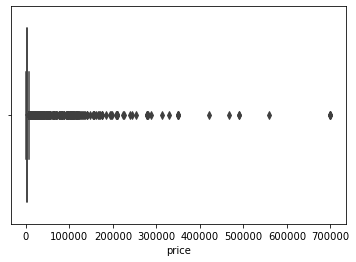

In [8]:
#We display a first boxplot of prices
sns.boxplot(df['price'])

We see that the data contains a lot of outliers. We are going to eliminate them

In [9]:
#We compute the 1st and 3rd quartile, the IQR, and then we eliminate what is above and below Qi+-1.5*IQR.
#We display the resulting dataframe, still called "df"
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3-q1

df['price'] = df['price'][df['price'].between(q1-1.5*iqr,q3+1.5*iqr)]
df

,name,neighbourhood,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,All-new Studio in Palermo with Amazing Balcony,Palermo,34643339.0,261355805.0,NaN,-34.59678,-58.42143,2720.0,7.0,61.0,4.83,1.0,107.0
1,170 m2.,Balvanera,3924999.0,20333847.0,NaN,-34.59899,-58.40530,NaN,20.0,0.0,NaN,1.0,0.0
2,APARTAMENT PREMIUM VIEW POOL GIM PARKING,Belgrano,38548368.0,198172215.0,NaN,-34.56474,-58.45729,1329.0,10.0,19.0,2.04,3.0,84.0
3,Cool Art Deco 3BR Overlooking Botanical Gardens,Palermo,42937146.0,13426.0,NaN,-34.58462,-58.41729,NaN,3.0,0.0,NaN,4.0,170.0
4,Feel free at a nice apartment single!!!,Parque Patricios,840855.0,1570656.0,NaN,-34.62969,-58.39601,1329.0,7.0,2.0,0.09,2.0,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23470,⭐️⭐️⭐️⭐️⭐️SPECIAL PRICE! Bright & modern apt i...,Palermo,29249730.0,160426105.0,NaN,-34.56783,-58.43334,3212.0,3.0,13.0,0.69,2.0,141.0
23471,㊗️RECOLETA ZEN ⭐Departamento y Edificio Nuevo⭐,Recoleta,38259425.0,32923411.0,NaN,-34.59742,-58.40501,2654.0,2.0,23.0,2.42,1.0,84.0
23472,有名な建築家が建てたﾚﾄﾛな雰囲気｡広いﾌﾟﾗｲﾍﾞｰﾄﾙｰﾑ｡\nｱｸｾｽ抜群｡,Balvanera,19749666.0,103758112.0,NaN,-34.60996,-58.40199,3569.0,10.0,4.0,0.12,1.0,174.0
23473,️‍ Relax Art Apartment - Big room,Monserrat,28157948.0,21698695.0,NaN,-34.61551,-58.37612,768.0,75.0,11.0,0.55,2.0,359.0


In [10]:
#We show a few descriptive statistics regarding prices
df['price'].describe()

count    21141.000000
mean      2360.467580
std       1360.249182
min          0.000000
25%       1395.000000
50%       2092.000000
75%       3138.000000
max       6647.000000
Name: price, dtype: float64

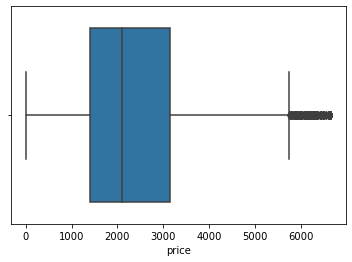

In [11]:
#We display a boxplot after having cleaning the price column. It is way better but not perfect since there are zeros...
sns.boxplot(df['price'])

DATA ANALYSIS

Now we are going to extract a sample of 50 items from the column "Price" from the name-price dataset and make statistics about it

C:\Users\antoi\anaconda3\lib\site-packages\numpy\lib\histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\antoi\anaconda3\lib\site-packages\numpy\lib\histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


(array([ 4., 13.,  8.,  4., 10.,  3.,  2.,  1.,  2.,  1.]),
 array([ 349. ,  838.9, 1328.8, 1818.7, 2308.6, 2798.5, 3288.4, 3778.3,
        4268.2, 4758.1, 5248. ]),
 <a list of 10 Patch objects>)

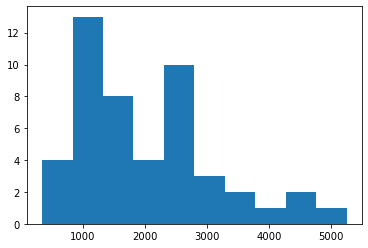

In [12]:
df_sample = df.sample(50)
plt.hist(df_sample['price'])

We are going to assume that the data are normally distributed, even if it is ALMOST distributed this way. Indeed it is a little skewed.

We make a CI about the sample

In [13]:
#We compute the confidence internvalfor the whole population
#confidence level = 0.95

sample_size = df['price'].size
sample_mean = np.mean(df['price'])
sem = df['price'].sem()

z_critical = stats.norm.ppf(q = 0.975)  # Get the z-critical value*

print("z-critical value:",z_critical)              # Check the z-critical value                        

pop_stdev = df['price'].std()  # Get the population standard deviation

margin_of_error = z_critical * (pop_stdev/math.sqrt(sample_size))

ci = (sample_mean - margin_of_error,
                       sample_mean + margin_of_error)  



print('The mean price of the "population" should be between this interval: ',ci)
print('The mean value is ',df['price'].mean())

z-critical value: 1.959963984540054
The mean price of the "population" should be between this interval:  (2342.9965258577945, 2377.9386348132252)
The mean value is  2360.46758033551


We are going to make CIs for each neighbourhood and display a dataframe including the total mean price

In [14]:
neighbourhoods = data.groupby('neighbourhood').median()['price'].index

confidence_level = 0.95
degrees_freedom = df.groupby('neighbourhood').count()['price'].values - 1 
mean_prices = df.groupby('neighbourhood').mean()['price'].values
err = df.groupby('neighbourhood').sem()['price'].values

ci = st.t.interval(confidence_level,
                   degrees_freedom,
                   mean_prices,
                   err)

mean_tot = df['price'].mean()

df_neigh_price_ci = pd.DataFrame({'Neighbourhood':neighbourhoods,
                                    'Minimum':ci[0],'Maximum':ci[1],
                                    'Mean':mean_tot})
df_neigh_price_ci

,Neighbourhood,Minimum,Maximum,Mean
0,Agronomia,1268.829587,2102.396219,2360.46758
1,Almagro,1716.414913,1853.589488,2360.46758
2,Balvanera,1757.541358,1894.722468,2360.46758
3,Barracas,1754.660141,2148.728017,2360.46758
4,Belgrano,2230.302788,2392.256110,2360.46758
5,Boca,1437.617121,1801.565419,2360.46758
6,Boedo,1252.863435,1605.136565,2360.46758
7,Caballito,1627.092666,1817.925767,2360.46758
8,Chacarita,2025.159842,2290.938276,2360.46758
9,Coghlan,1880.791013,2437.458987,2360.46758


Now we are engaging in the exploration, cleaning and analysing of availabilities

(array([3913.,  517., 3197.,  556., 3686.,  518.,  379.,  931.,  854.,
        8735.]),
 array([  0. ,  36.5,  73. , 109.5, 146. , 182.5, 219. , 255.5, 292. ,
        328.5, 365. ]),
 <a list of 10 Patch objects>)

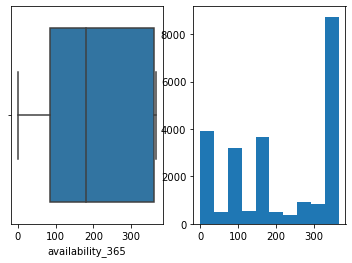

In [33]:
#We display a boxplot and a histogram of availabilities
fig, ax=plt.subplots(1,2)
sns.boxplot(df['availability_365'],ax=ax[0])
plt.hist(df['availability_365'])

We see that is is not normally distributed since a lot a data are above the median

In [16]:
#A few descriptive statistics of availabilities
df['availability_365'].describe()

count    23286.000000
mean       209.243245
std        138.462194
min          0.000000
25%         85.000000
50%        180.000000
75%        359.000000
max        365.000000
Name: availability_365, dtype: float64

We already have a sample of the main dataframe. Let's extract availabilities and make a barplot

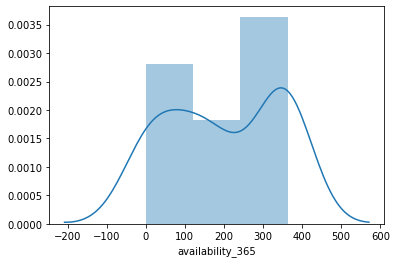

In [17]:
sns.distplot(df_sample['availability_365'])

The distribution is not centered

In [18]:
#confidence level = 0.95
sample_size = df['availability_365'].size
sample_mean = np.mean(df['availability_365'])
error=df['availability_365'].sem()

z_critical = stats.norm.ppf(q = 0.975)  # Get the z-critical value*

print("z-critical value:",z_critical)              # Check the z-critical value                        

pop_stdev = df['availability_365'].std()  # Get the population standard deviation

margin_of_error = z_critical * (pop_stdev/math.sqrt(sample_size))

ci = (sample_mean - margin_of_error,
                       sample_mean + margin_of_error)  


print('Availability from the sample: ',ci)
print('The mean value is ',df['availability_365'].mean())

z-critical value: 1.959963984540054
Availability from the sample:  (207.4648348359821, 211.02165452542985)
The mean value is  209.24324468070597


Mean do match with the CI of the sample. Let's make it now per neighbourhoods:

In [19]:
neighbourhoods = df.groupby('neighbourhood').median()['price'].index

confidence_level = 0.95
degrees_freedom = df.groupby('neighbourhood').count()['availability_365'].values - 1 
mean_availabilities = df.groupby('neighbourhood').mean()['availability_365'].values
error = df.groupby('neighbourhood').sem()['availability_365'].values

mean_tot_availability = df['availability_365'].mean()

ci = st.t.interval(confidence_level,
                   degrees_freedom,
                   mean_availabilities,
                   error)


df_neighbourhood_ci = pd.DataFrame({'Neighbourhood':neighbourhoods,
                                    'Minimum':ci[0],'Maximum':ci[1],
                                    'Mean':mean_tot_availability})
df_neighbourhood_ci

,Neighbourhood,Minimum,Maximum,Mean
0,Agronomia,131.559975,235.988412,209.243245
1,Almagro,179.319052,197.692564,209.243245
2,Balvanera,190.644497,207.270633,209.243245
3,Barracas,181.155572,223.754449,209.243245
4,Belgrano,185.518040,202.130223,209.243245
5,Boca,176.631438,224.905875,209.243245
6,Boedo,151.634431,205.900657,209.243245
7,Caballito,145.669290,172.109233,209.243245
8,Chacarita,190.847760,219.104017,209.243245
9,Coghlan,133.955030,197.733859,209.243245


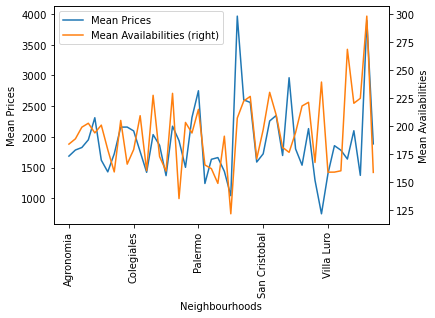

In [20]:
df_neigh_means = pd.DataFrame({'Neighbourhoods':neighbourhoods,
                               'Mean Prices':mean_prices,
                               'Mean Availabilities':mean_availabilities})

graph=df_neigh_means.plot(x='Neighbourhoods',secondary_y='Mean Availabilities',rot=90)
graph.set_ylabel('Mean Prices')
graph.right_ax.set_ylabel('Mean Availabilities')

plt.show()

Conclusion: There are patterns between mean availabilities and mean prices, except for few neighbourhoods

Now we are going to make an analysis of reviews per month. We take back our "data" dataframe.

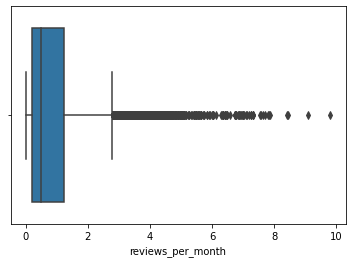

In [21]:
#We display a boxplot of reviews per month
sns.boxplot(data['reviews_per_month'])

We delete all the absurd values

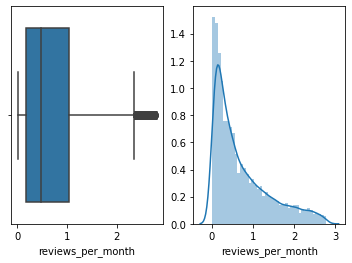

In [22]:
#We do the same as per price in deleting absurd values
q_1 = data['reviews_per_month'].quantile(0.25)
q_3 = data['reviews_per_month'].quantile(0.75)
i_q_r = q_3-q_1
data['reviews_per_month'] = data['reviews_per_month'][data['reviews_per_month'].between(q_1-1.5*i_q_r,q_3+1.5*i_q_r)]

fig,ax=plt.subplots(1,2)
sns.boxplot(data['reviews_per_month'],ax=ax[0])
sns.distplot(data['reviews_per_month'],ax=ax[1])

Not normally distributed but left-skewed

let's look at some descriptive statistics:

In [23]:
data['reviews_per_month'].describe()

count    16135.000000
mean         0.708999
std          0.673360
min          0.010000
25%          0.180000
50%          0.470000
75%          1.050000
max          2.790000
Name: reviews_per_month, dtype: float64

We see that there are a lot of values between 0 and 1

Let's make a statistic test for reviews per month. We define H0: mean = 0.708999 and H1: mean!=0.708999. In other terms we define a bilateral z test because sigma is known, our population is greater than 30. 

We are going to delete NaN because the statistic test does not read them

In [24]:
#We drop NaN from availabilities
df_reviews=data[['reviews_per_month','availability_365']].dropna()
df_reviews

,reviews_per_month,availability_365
0,0.27,176
1,0.16,362
2,0.05,359
4,1.80,359
6,0.03,359
...,...,...
23720,1.00,176
23742,1.00,85
23746,1.00,280
23758,1.00,0


In [25]:
#We call the test pval (even if it displays the z-score and the p-value)
pval = stests.ztest(x1=df_reviews['reviews_per_month'],
                    x2=None,
                    value=data['reviews_per_month'].mean(),
                    alternative='two-sided')

#We return the p-value and conclude if it is significant or not
print(float(pval[1]))
if pval[1]<0.05:
    print("reject null hypothesis")
else:
    print("accept null hypothesis because",pval[1],"> 0.05")

0.999999999999081
accept null hypothesis because 0.999999999999081 > 0.05


In [26]:
#We display a dataframe grouped by minimum nights and availabilites
df_nights_availability = data.groupby(['minimum_nights','availability_365']).mean().reset_index()
df_nights_availability

,minimum_nights,availability_365,id,host_id,neighbourhood_group,latitude,longitude,price,number_of_reviews,reviews_per_month,calculated_host_listings_count
0,1,0,2.527804e+07,1.163237e+08,NaN,-34.594748,-58.422459,3275.287562,7.951244,0.495471,2.641791
1,1,1,3.112074e+07,1.415471e+08,NaN,-34.591297,-58.420588,3690.083333,19.333333,0.738571,5.416667
2,1,2,3.337880e+07,1.745351e+08,NaN,-34.589757,-58.431413,2405.833333,17.000000,0.941250,1.833333
3,1,3,2.893189e+07,1.631475e+08,NaN,-34.602510,-58.382630,1186.000000,101.000000,NaN,1.000000
4,1,4,4.366948e+07,3.306760e+07,NaN,-34.552650,-58.459420,6983.000000,0.000000,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
2742,1100,365,3.350697e+07,2.490347e+08,NaN,-34.584840,-58.419470,767.000000,1.000000,0.070000,2.000000
2743,1124,361,1.305099e+06,7.094891e+06,NaN,-34.622620,-58.367060,2312.000000,13.000000,0.160000,2.000000
2744,1125,0,3.614447e+07,2.718583e+08,NaN,-34.597510,-58.395950,976.000000,2.000000,0.170000,1.000000
2745,1125,178,1.644130e+07,8.014137e+07,NaN,-34.598890,-58.401360,2023.000000,5.000000,0.130000,1.000000


In [34]:
#We do the same process as for reviews per month
z=stests.ztest(x1=df_nights_availability['minimum_nights'],
               x2=None,
               value=data['minimum_nights'].mean(),
               alternative='two-sided')
z

print(float(z[1]))
if z[1]<0.05:
    print("reject null hypothesis, not significant")
else:
    print("accept null hypothesis because",z[1],"> 0.05")

6.917586654996214e-25
reject null hypothesis, not significant


Conclusions are done at the respective questions

Now we are going to check the means of differents neighbourhoods

In [28]:
#We are going to display a dataframe with means per neighbourhoods
neighbourhoods = data.groupby('neighbourhood').mean()['price'].index
mean_price = df.groupby('neighbourhood').mean()['price'].values

df_neighbourhood_price = pd.DataFrame({'Neighbourhood':neighbourhoods,
                                    'Mean price':mean_price})
df_neighbourhood_price

,Neighbourhood,Mean price
0,Agronomia,1685.612903
1,Almagro,1785.002200
2,Balvanera,1826.131913
3,Barracas,1951.694079
4,Belgrano,2311.279449
5,Boca,1619.591270
6,Boedo,1429.000000
7,Caballito,1722.509217
8,Chacarita,2158.049059
9,Coghlan,2159.125000


In [29]:
bsas_geo = r'neighbourhoods.geojson'
bsas_map = folium.Map(location=[-34.603722,-58.381592], zoom_start=11,)
bsas_map.choropleth(
    geo_data=bsas_geo,
    data=df_neighbourhood_price,
    columns=['Neighbourhood', 'Mean price'],
    key_on='feature.properties.neighbourhood',
    fill_color='YlOrRd', 
    fill_opacity=0.7, 
    line_opacity=0.2,
    legend_name='Mean prices across various neighbourhoods'
)
bsas_map

C:\Users\antoi\anaconda3\lib\site-packages\folium\folium.py:411: FutureWarning: The choropleth  method has been deprecated. Instead use the new Choropleth class, which has the same arguments. See the example notebook 'GeoJSON_and_choropleth' for how to do this.
  warnings.warn(


CORRELATION AND REGRESSION

Now we are going to do a correlation matrix to see the correlation between the variables

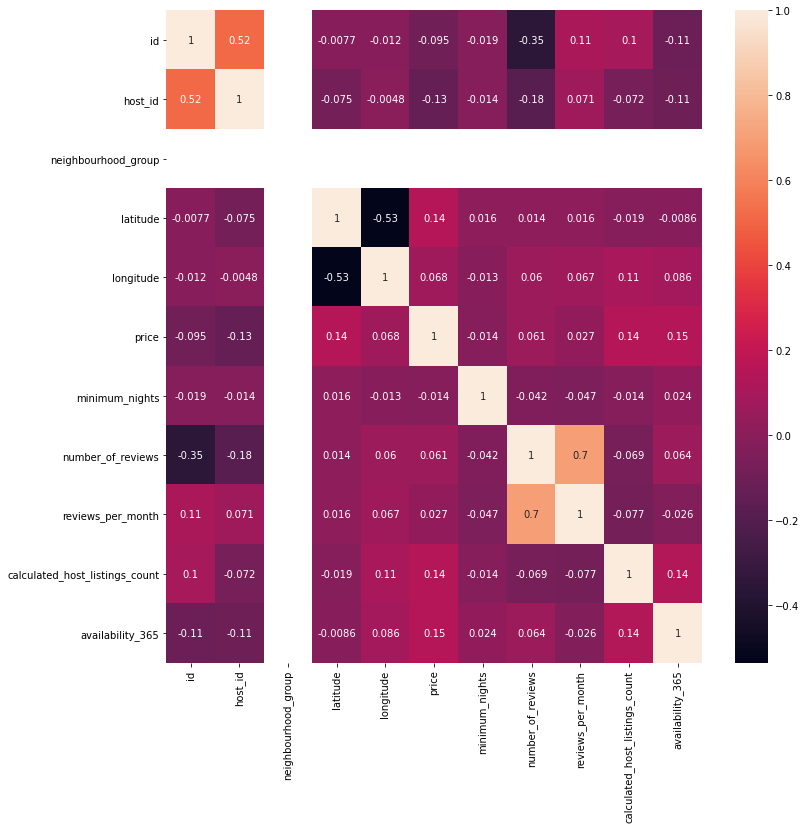

In [30]:
#We display a correlation matrix under the form of a thermic table to see which variables are correlated or not.
#To do this we use the "df" dataframe.
width = 12
height = 12
plt.figure(figsize=(width, height))
matrix = df.corr()
#df.corr().unstack().sort_values().drop_duplicates()
sns.heatmap(data=matrix,annot=True)

There are no meaningful correlations (e.g. latitude, longitude; number of reviews and reviews per month; etc.) The only meaningful correlation is reviews per month and ID which is of -0.35. What seems to be correlated to price is availability (r = 0.15).

We are going to make a regression analysis between price and availability

In [31]:
lm = LinearRegression()

X = data[['availability_365']]
Y = data['price']

lm.fit(X,Y)

#components of the Y^ equation
print("Y^ =",lm.intercept_,"+",lm.coef_,"X")

Y^ = 2855.377739074219 + [11.00235553] X


The equation is Y^ = 2855.37 + 11X. It is a positive relationship.

Now we are going to display the graph of price per availabilities:

(0.0, 6979.35)

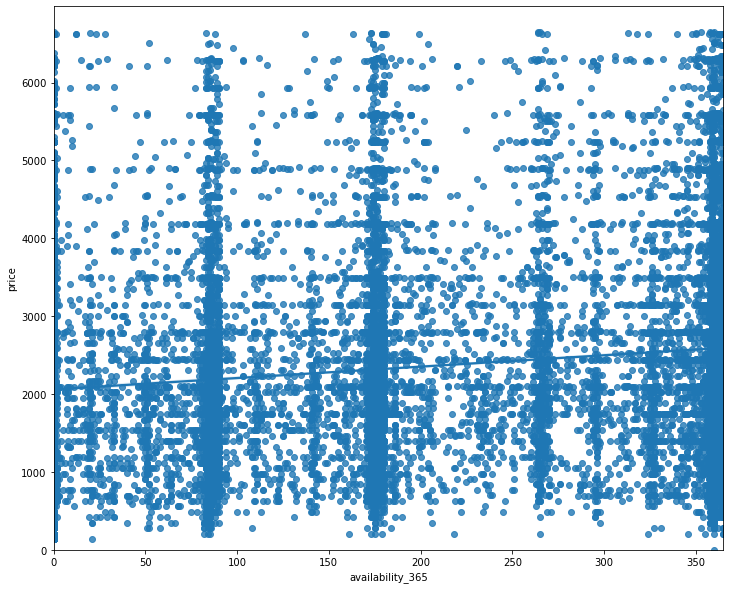

In [32]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x="availability_365", y="price", data=df)
plt.ylim(0,)

The relationship between price and availability is not visible at all.